In [44]:
from pixell import reproject, enmap, enplot
import numpy as np
import select_and_orient as sao
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy import wcs as astwcs
import sys
import stacking_functions as sf
import healpy as hp
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
def filament(ra0, dec0, angle, length, width, amplitude=1):
    """
    Elliptical Gaussian elongated along `angle`.

    angle is measured counter-clockwise from RA direction.
    """

    x = (ra - ra0) * np.cos(dec0)
    y = dec - dec0

    # Rotate coordinates
    ca = np.cos(angle)
    sa = np.sin(angle)

    xp =  ca*x + sa*y
    yp = -sa*x + ca*y

    return amplitude * np.exp(
        -0.5 * (
            (xp / length)**2 +
            (yp / width)**2
        )
    )


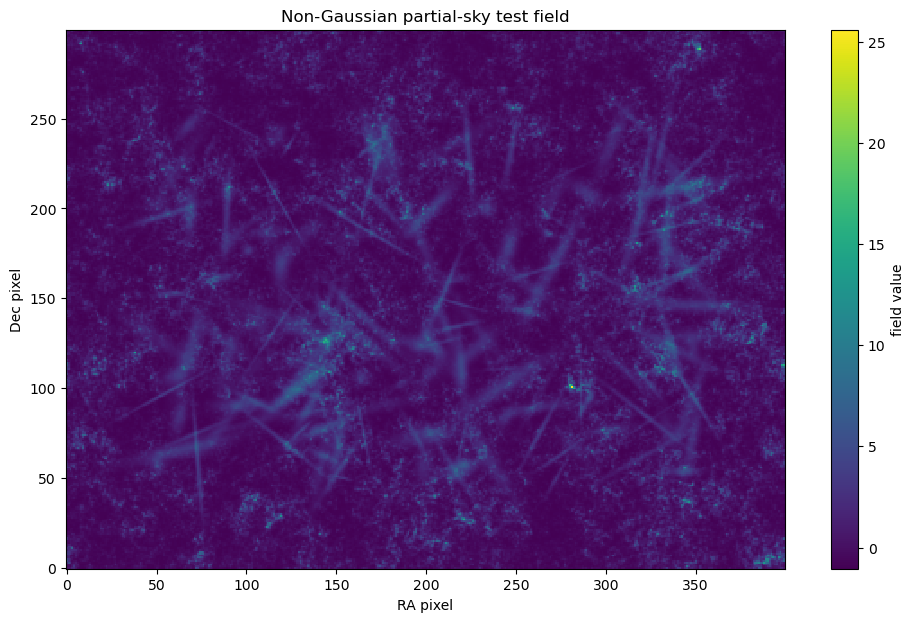

In [183]:
import numpy as np
import matplotlib.pyplot as plt

from pixell import enmap, utils


# ------------------------------------------------------------
# 1. Partial-sky geometry
# ------------------------------------------------------------

res = 0.1 * utils.degree

# [dec_min, ra_min], [dec_max, ra_max]
box = np.array([
    [-15, -20],
    [ 15,  20],
]) * utils.degree

shape, wcs = enmap.geometry(pos=box, res=res, proj="car")


# ------------------------------------------------------------
# 2. Correlated Gaussian background
# ------------------------------------------------------------

# Multipoles corresponding roughly to:
#   large scales  -> low ell
#   small scales  -> high ell

lmax = int(np.pi / res)

ells = np.arange(lmax + 1)

# Smooth-ish red spectrum
cl = np.zeros_like(ells, dtype=float)

good = ells > 0
cl[good] = 1.0 / (ells[good]**2 + 30**2)

# Suppress very small scales
cl *= np.exp(-(ells / 2500.)**4)

# Generate Gaussian random field
m = enmap.rand_map(shape, wcs, cl, scalar=True, seed=1234)


# Normalize
m = (m - np.mean(m)) / np.std(m)


# ------------------------------------------------------------
# 3. Make it non-Gaussian
# ------------------------------------------------------------

# Lognormal-like transformation
sigma = 0.8

m = np.exp(sigma * m - 0.5 * sigma**2)

# Normalize again
m = (m - np.mean(m)) / np.std(m)


# ------------------------------------------------------------
# 4. Add elongated structures
# ------------------------------------------------------------

pos = enmap.posmap(shape, wcs)

dec = pos[0]
ra  = pos[1]

ras, decs = [], []
ras_offset = []
decs_offset = []
for i in range(200):
    # Random position
    ra0  = np.random.uniform(-15, 15) * utils.degree
    dec0 = np.random.uniform(-10, 10) * utils.degree

    # Random orientation
    angle = np.random.uniform(-np.pi, np.pi)

    # Random length and width
    length = np.random.uniform(0.03, 2) * utils.degree
    width  = np.random.uniform(0.05, 0.3) * utils.degree

    # Random amplitude
    amplitude = np.random.uniform(1, 4)

    m += filament(
        ra0=ra0,
        dec0=dec0,
        angle=angle,
        length=length,
        width=width,
        amplitude=amplitude,
    )
    ras.append(ra0)
    decs.append(dec0)
    # save points that are positioned slightly up or down the filament
    ras_offset.append(ra0 + np.random.uniform(-length, length) * np.cos(angle) + np.random.uniform(-width*2, width*2) * np.sin(angle))
    decs_offset.append(dec0 + np.random.uniform(-length, length) * np.sin(angle) - np.random.uniform(-width*2, width*2) * np.cos(angle))
# # Add structures with deliberately different orientations
# m += filament(
#     ra0=-12 * utils.degree,
#     dec0=  5 * utils.degree,
#     angle= 25 * utils.degree,
#     length=3 * utils.degree,
#     width=0.5 * utils.degree,
#     amplitude=4.0,
# )

# m += filament(
#     ra0=  5 * utils.degree,
#     dec0= -5 * utils.degree,
#     angle=-40 * utils.degree,
#     length=5 * utils.degree,
#     width=0.2 * utils.degree,
#     amplitude=5,
# )

# m += filament(
#     ra0= 12 * utils.degree,
#     dec0=  9 * utils.degree,
#     angle=70 * utils.degree,
#     length=4 * utils.degree,
#     width=0.4 * utils.degree,
#     amplitude=3,
# )


# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

plt.imshow(
    m,
    origin="lower",
    interpolation="nearest",
)

plt.colorbar(label="field value")
plt.xlabel("RA pixel")
plt.ylabel("Dec pixel")
plt.title("Non-Gaussian partial-sky test field")

plt.show()

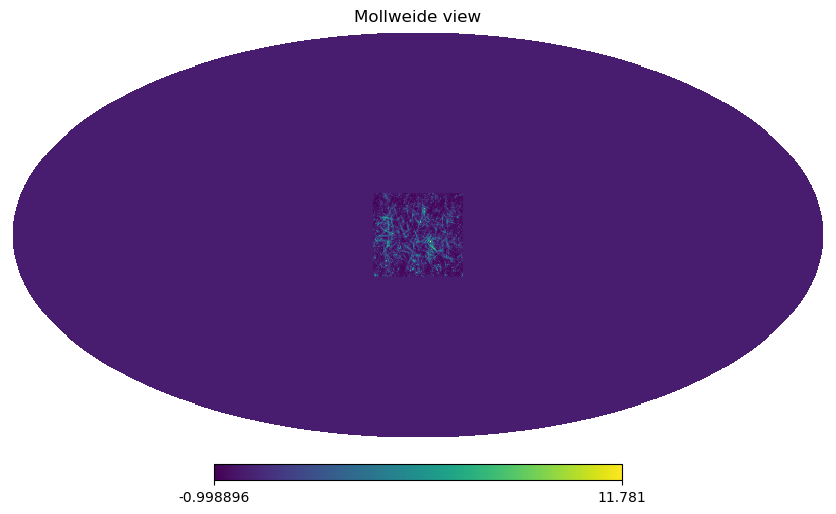

In [184]:
# make  healpy version
m_hp = reproject.map2healpix(m, nside=1024, lmax=3*1024, method='spline')
hp.mollview(m_hp)

In [185]:
# Define a function to show on the map where the clusters are:
def mask_srcs(shape,wcs,srcs,radius_arcmin):
    r = np.deg2rad(radius_arcmin/60.)
    return enmap.distance_from(shape,wcs,srcs, rmax=r) >= r
     

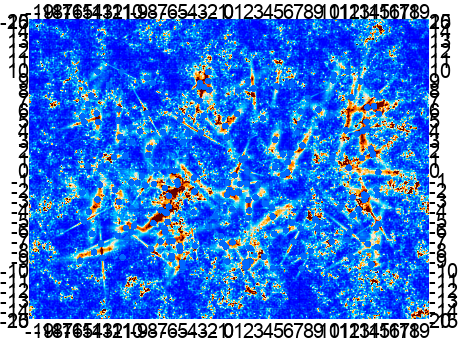

In [186]:
# points = np.vstack(([5, -12], [-5, 5], [9, 12])) * utils.degree
# print(points)
#points in [dec,ra] order
points = np.vstack((decs, ras))
# print(points)
# show on map
srcmap = mask_srcs(shape,wcs,points,20)
enplot.pshow(srcmap*m)

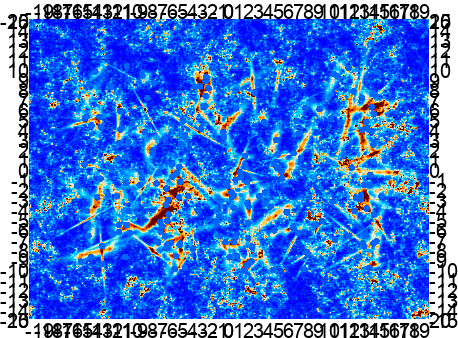

In [187]:
srcmap_offset = mask_srcs(shape,wcs,np.vstack((decs_offset, ras_offset)),20)
enplot.pshow(srcmap_offset*m)

In [171]:
# get the orientations
alpha, e, nu, xpol, ypol = sao.measure_orientation_QU(np.rad2deg(ras), np.rad2deg(decs), m_hp)

Computed rms of the field: 0.2316
grad_alpha_y: -0.11622830087938507 0.10297942667040191 0.475


In [175]:
# stack the map

# make a Chunk object
Chunk = sf.Chunk(np.rad2deg(ras), np.rad2deg(decs), alpha=alpha, x_asym=xpol, y_asym=ypol)
geom = sf.StackGeometry(2, .1)
stack = sf.stackChunk(Chunk, geom, orient='asym_xy', imap=m)


shape is (np.int64(41), np.int64(41))


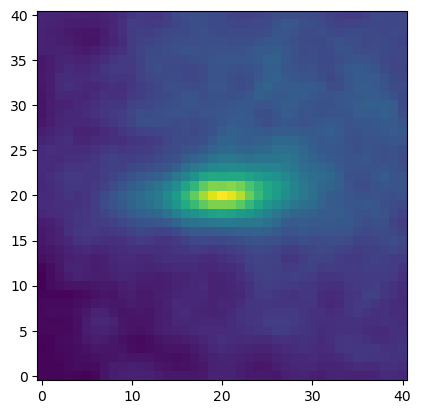

In [176]:
plt.imshow(stack, origin='lower')

In [188]:
m_hp_smthd = hp.smoothing(m_hp, fwhm=np.deg2rad(0.5))

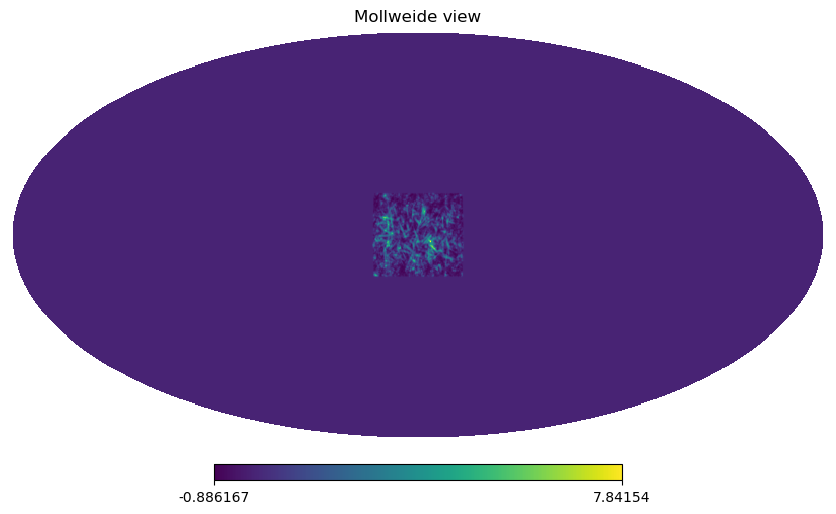

In [189]:
hp.mollview(m_hp_smthd)

In [239]:
# now with the offset ras and decs, test asymmetry
# get the orientations
alpha_off, e, nu, xpol_off, ypol_off = sao.measure_orientation_QU(np.rad2deg(ras_offset), np.rad2deg(decs_offset), m_hp_smthd, mode='potential')

Computed rms of the field: 0.0129
grad_alpha_y: -0.006939116617388323 0.007620071390009261 0.565


In [254]:
Chunk_offset = sf.Chunk(np.rad2deg(ras_offset), np.rad2deg(decs_offset), alpha=alpha_off, x_asym=xpol_off, y_asym=ypol_off)
stack_offset = sf.stackChunk(Chunk_offset, geom, orient='asym_xy', imap=m)

Text(0.5, 1.0, 'xy-asymmetric')

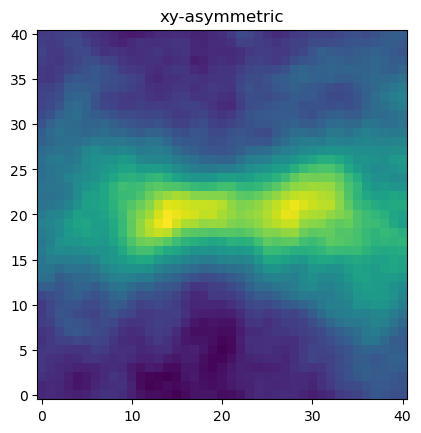

In [255]:
plt.imshow(stack_offset, origin='lower')
plt.title("xy-asymmetric")

In [256]:
# do some cuts
cuts = (e > 0.3) & (nu>2)

Chunk_offset_cut = sf.Chunk(np.asarray(np.rad2deg(ras_offset))[cuts], np.asarray(np.rad2deg(decs_offset))[cuts], alpha=alpha_off[cuts], x_asym=xpol_off[cuts], y_asym=ypol_off[cuts])
stack_offset = sf.stackChunk(Chunk_offset_cut, geom, orient='asym_xy', imap=m)

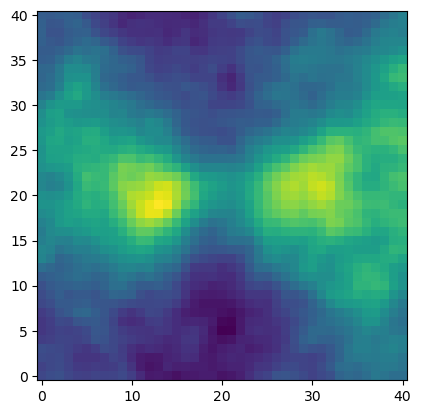

In [257]:
plt.imshow(stack_offset, origin='lower')